In [1]:
import numpy as np
from scipy.special import expit
import matplotlib.pyplot as plt



def true_conditional_likelihood(X, eps=1e-12):
    return np.where(
        X[:, 0] > 0,
        np.where(X[:, 1] > 2 * np.sin(X[:, 0] * 4), 1 - eps, eps),
        expit(X[:, 1]),
    )

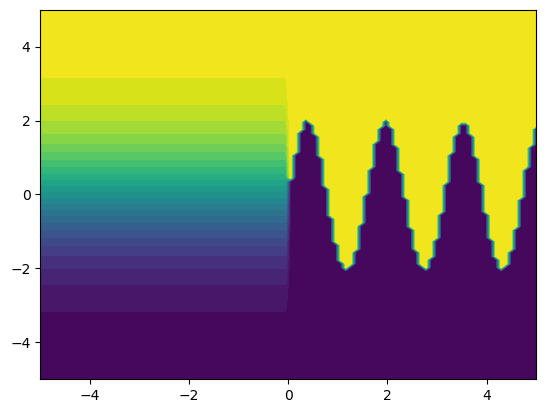

In [2]:
n_grid_steps = 100
grid_0 = np.linspace(-5, 5, n_grid_steps)
grid_1 = np.linspace(-5, 5, n_grid_steps)
X0, X1 = np.meshgrid(grid_0, grid_1)
X_grid = np.concatenate([X0.reshape(-1, 1), X1.reshape(-1, 1)], axis=1)

plt.contourf(
    X0,
    X1,
    true_conditional_likelihood(X_grid).reshape(n_grid_steps, n_grid_steps),
    levels=25,
);

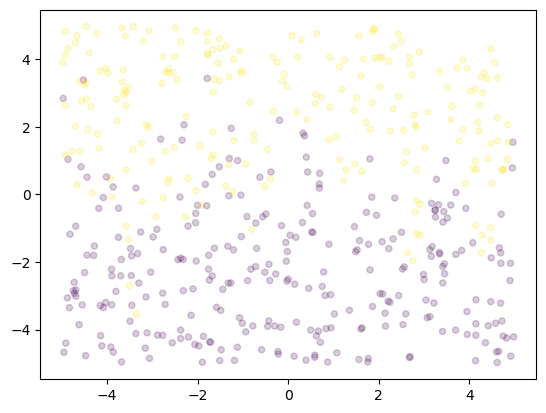

In [26]:
def sample_from_model(n_samples, random_state=None):
    rng = np.random.default_rng(random_state)
    X = rng.normal(loc=0, scale=2, size=(n_samples, 2))
    X = rng.uniform(low=-5, high=5, size=(n_samples, 2))
    y = rng.binomial(1, true_conditional_likelihood(X))
    return X, y


X, y = sample_from_model(500, random_state=0)
_ = plt.scatter(X[:, 0], X[:, 1], c=y, s=20, alpha=0.2)

In [27]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=10_000, n_jobs=-1,random_state=0)
clf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [28]:
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

clf = make_pipeline(
    SplineTransformer(degree=3, n_knots=30),
    PolynomialFeatures(degree=2, include_bias=False, interaction_only=True),
    BaggingClassifier(
        estimator=LogisticRegression(C=1_000, max_iter=1000),
        n_estimators=1_000,
        max_samples=100,
        n_jobs=-1,
        random_state=0,
    ),
)
clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('splinetransformer', ...), ('polynomialfeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_knots n_knots: int, default=5Number of knots of the splines if `knots` equals one of{'uniform', 'quantile'}. Must be larger or equal 2. Ignored if `knots`is array-like.",30
,"degree degree: int, default=3The polynomial degree of the spline basis. Must be a non-negativeinteger.",3
,"knots knots: {'uniform', 'quantile'} or array-like of shape (n_knots, n_features), default='uniform'Set knot positions such that first knot <= features <= last knot.- If 'uniform', `n_knots` number of knots are distributed uniformly from min to max values of the features.- If 'quantile', they are distributed uniformly along the quantiles of the features.- If an array-like is given, it directly specifies the sorted knot positions including the boundary knots. Note that, internally, `degree` number of knots are added before the first knot, the same after the last knot.",'uniform'
,"extrapolation extrapolation: {'error', 'constant', 'linear', 'continue', 'periodic'}, default='constant'If 'error', values outside the min and max values of the trainingfeatures raises a `ValueError`. If 'constant', the value of thesplines at minimum and maximum value of the features is used asconstant extrapolation. If 'linear', a linear extrapolation is used.If 'continue', the splines are extrapolated as is, i.e. option`extrapolate=True` in :class:`scipy.interpolate.BSpline`. If'periodic', periodic splines with a periodicity equal to the distancebetween the first and last knot are used. Periodic splines enforceequal function values and derivatives at the first and last knot.For example, this makes it possible to avoid introducing an arbitraryjump between Dec 31st and Jan 1st in spline features derived from anaturally periodic ""day-of-year"" input feature. In this case it isrecommended to manually set the knot values to control the period.",'constant'
,"include_bias include_bias: bool, default=TrueIf False, then the last spline element inside the data rangeof a feature is dropped. As B-splines sum to one over the spline basisfunctions for each data point, they implicitly include a bias term,i.e. a column of ones. It acts as an intercept term in a linea

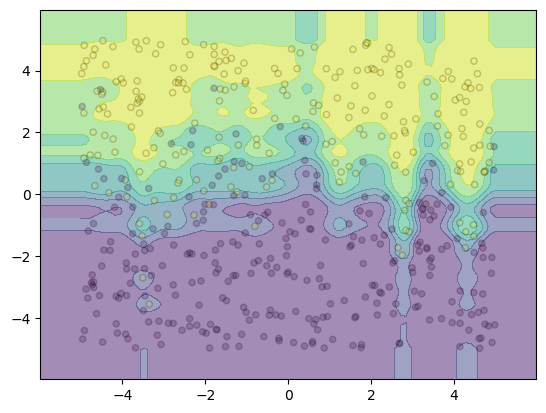

In [29]:
from sklearn.inspection import DecisionBoundaryDisplay

display = DecisionBoundaryDisplay.from_estimator(
    clf, X, response_method="predict_proba", alpha=0.5
)
_ = display.ax_.scatter(X[:, 0], X[:, 1], c=y, edgecolors="black", s=20, alpha=0.2)

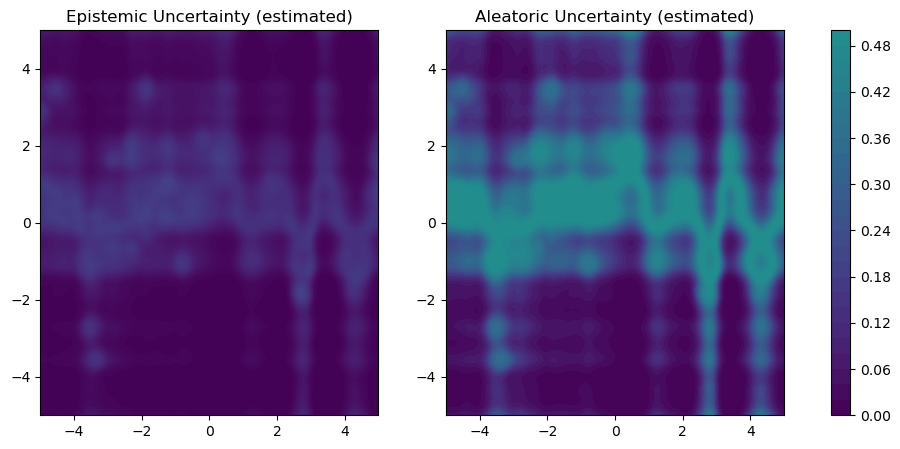

In [30]:
def epistemic_uncertainty(estimator, X):
    """Estimate epistemic uncertainty as the var of the predictions of all trees."""
    if hasattr(estimator, "steps") and hasattr(estimator[-1], "estimators_"):
        X = estimator[:-1].transform(X)
        estimator = estimator[-1]

    all_proba = np.array(
        [tree.predict_proba(X)[:, 1] for tree in estimator.estimators_]
    )
    return np.var(all_proba, axis=0)


def aleatoric_uncertainty(estimator, X):
    """Estimate aleatoric uncertainty."""
    proba = estimator.predict_proba(X)[:, 1]
    return 1 - proba * proba - (1 - proba) * (1 - proba)


epistemic_uncertainty_values = epistemic_uncertainty(clf, X_grid)
aleatoric_uncertainty_values = aleatoric_uncertainty(clf, X_grid)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].contourf(
    X0,
    X1,
    epistemic_uncertainty_values.reshape(n_grid_steps, n_grid_steps),
    levels=25,
    vmin=0.,
    vmax=1.,
)
axes[0].set_title("Epistemic Uncertainty (estimated)")
contourf = axes[1].contourf(
    X0,
    X1,
    aleatoric_uncertainty_values.reshape(n_grid_steps, n_grid_steps),
    levels=25,
    vmin=0.,
    vmax=1.,
)
axes[1].set_title("Aleatoric Uncertainty (estimated)")
_ = fig.colorbar(contourf, ax=axes.ravel().tolist())